In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob
import numpy as np
import seaborn as sns

# Main Cases -1205 --> Ropes 1302 --> Thrusters

In [2]:
#gt=sorted(glob("/home/saab/Desktop/2024_UWR/Analysis/gt/13*/*corrected*1302.csv"))
gt=sorted(glob("/home/saab/Desktop/2024_UWR/Analysis/gt/6*/*1205.csv"))
gt

['/home/saab/Desktop/2024_UWR/Analysis/gt/6Nov/output_1205.csv']

## Other cases --> effects of different parameters

In [66]:
cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_case_13*Nov_*"))
confidence_cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/confidence_case_13*_*"))
imus=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_IMU_case_13*"))

In [5]:
cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_6_Nov_case_????.csv"))
confidence_cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_6*confidence_case_????.csv"))
imus=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/CSVs/output_6*IMU_case_????.csv"))

In [5]:
confidence_cases_2=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/CSVs/output_13*confidence_case_*"))
cases_2=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/CSVs/output_6_Nov_case_????.csv"))

In [77]:
cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_case_6thNov_1205*best*.csv"))
confidence_cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/confidence_case_6thNov_1205*best*.csv"))
imus=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_IMU_case_6thNov_1205*best*.csv"))

In [78]:
imus

['/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_6thNov_1205_best_t1_.csv',
 '/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_6thNov_1205_best_t2_.csv',
 '/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_6thNov_1205_best_t2_IMU_only.csv']

In [83]:
cases

['/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_best_t1_.csv',
 '/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_best_t2_.csv']

In [8]:
ed_1=[]
ed_2=[]
ed_3=[]
for case in confidence_cases[:]:
    df=pd.read_csv(case)
    print(case.split("/")[-1])
    expected_diff_1=np.abs(np.mean(np.diff(df["Sonar_distance_1"]))/len(df))
    expected_diff_2=np.abs(np.mean(np.diff(df["Sonar_distance_2"]))/len(df))
    expected_diff_3=np.abs(np.mean(np.diff(df["Sonar_distance_3"]))/len(df))
    ed_1.append(expected_diff_1)
    ed_2.append(expected_diff_2)
    ed_3.append(expected_diff_3)
    print("X",expected_diff_1,"Y:",expected_diff_2,"Z:",expected_diff_3)

In [9]:
print(np.mean(ed_1))
print(np.mean(ed_2))
print(np.mean(ed_3))

nan
nan
nan


/home/saab/anaconda3/envs/vehicle/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/saab/anaconda3/envs/vehicle/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [10]:
i=0
plt.figure(figsize=(5,5))
for case in cases[:]:
    try:
    
        df=pd.read_csv(case)
        #plt.title("Angles")
        plt.plot(df["Timestamp"]-df["Timestamp"][0],df["Angle_X"]-df["Angle_X"][0],label="Roll")
        #plt.figure()
        plt.plot(df["Timestamp"]-df["Timestamp"][0],df["Angle_Y"]-df["Angle_Y"][0],label="Pitch")
        
        #plt.figure()
        plt.plot(df["Timestamp"]-df["Timestamp"][0],df["Angle_Z"]-df["Angle_Z"][0],label="Yaw")
        ls=np.ones_like(df["Angle_Z"])
        #plt.plot(np.mean(-df["Angle_Z"])*ls)
        print(np.mean(-df["Angle_Z"]))
        #plt.xlim(0,2)
        plt.ylim(-25,25)
        plt.xlabel('Time (s)')
        plt.ylabel("Angle (deg)")
        plt.grid(True)
        plt.legend()
        i+=1
    except:
        print("No angles")

<Figure size 500x500 with 0 Axes>

In [5]:
import matplotlib.patches as patches
def plot_ellipses(ax, df,s1="Sonar_distance_2",s2="Sonar_distance_1",c1="Confidence_2",c2="Confidence_1",scale=5,rezero=False):
    for idx, row in df.iterrows():
        # Confidence for color intensity, using the average of x and y confidence
        #print(row)
        width = scale*(1-(row[c1]) / 100)
        height =scale*(1-(row[c2]) / 100)
        #print(width)
        #print(height)
        if(rezero==False):
        # Draw ellipse to represent confidence in x and y
            ellipse = patches.Ellipse(((row[s1])/1000, (row[s2]/1000)), width, height,
                                  color=(0, 1, 0, 0.25), fill=True)
        else:
            ellipse = patches.Ellipse(((row[s1]-df[s1].iloc[0])/1000, (row[s2]-df[s2].iloc[0])/1000), width, height,
                                color=(0, 1, 0, 0.25), fill=True)
        ax.add_patch(ellipse)

In [64]:
cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_case*1205*t2*.csv"))
confidence_cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/confidence_case*1205*t2*.csv"))
imus=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_IMU*1205*t2*.csv"))
gt=sorted(glob("/home/saab/Desktop/2024_UWR/Analysis/gt/6*/*1205.csv"))
gt

['/home/saab/Desktop/2024_UWR/Analysis/gt/6Nov/output_1205.csv']

In [68]:
#1205
gt_df=pd.read_csv(gt[0])
div_flows_mean=gt_df["Z"].to_numpy()
#displacements=np.sqrt(gt_df["X"].to_numpy()**2 + gt_df["Y"].to_numpy()**2)
displacements_x=gt_df["X"].to_numpy()
displacements_z=gt_df["Y"].to_numpy()
# Calculate cumulative displacement
displacements=np.sqrt(gt_df["X"].to_numpy()**2 + gt_df["Y"].to_numpy()**2)
cumulative_displacement_x = np.cumsum(div_flows_mean)
cumulative_displacement_y =np.cumsum(displacements)
cumulative_displacement_z =np.cumsum(displacements_z)*0.001
cumulative_displacement_x*=0.5/abs(cumulative_displacement_x[0]-cumulative_displacement_x[cumulative_displacement_x.shape[0]-1])
cumulative_displacement_y*=6/abs(cumulative_displacement_y[0]-cumulative_displacement_y[cumulative_displacement_y.shape[0]-1])
cumulative_displacement_x+=1
cumulative_displacement_y=6.75-cumulative_displacement_y

/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_6thNov_1205_best_t2_.csv
0       3.832273
1       3.832340
2       3.832545
3       3.833885
4       3.840096
          ...   
1250    0.496626
1251    0.488438
1252    0.485500
1253    0.479871
1254    0.478777
Name: Pose_Y, Length: 1255, dtype: float64
KF error _X 2.0267086000834005
KF error _Y 0.09334144320788476
KF error _Z 0.15745476037960562
KF var _X: 3.352469612383382
KF var _Y: 4.680873277636797
KF var _Z: 0.014675241007089387
1255
/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_6thNov_1205_best_t2_IMU_only.csv
IMU error _X 4.36056103758429
IMU_x_var 6.88967189761057
IMU error _Y 2.460588694165114
IMU_y_var 2.978998543424492
IMU error _Z 10299.809278076293
IMU_z_var 49399432.75069618
1498
/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_6thNov_1205_t2_ptn_only.csv
ignore
0       3.830852
1       3.830853
2       3.830853
3       3.830853
4       3.830854
          ...   
1413    0.491995
1414    0.487226
1415    0.4

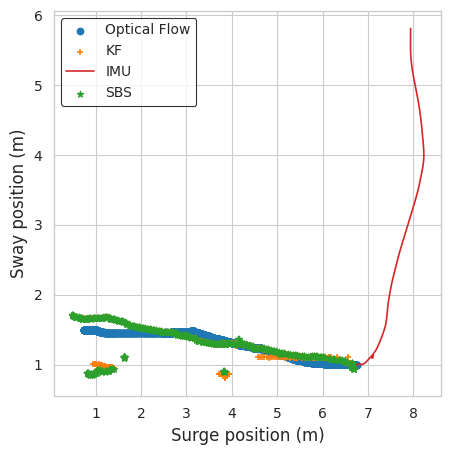

In [69]:
i=0
fig, ax = plt.subplots(1,1,figsize=(5, 5),sharey=True)
ax.scatter(cumulative_displacement_y,cumulative_displacement_x,label="Optical Flow",color="tab:blue")

i=1
for case in imus[:]:
    print(case)
    df=pd.read_csv(case)



    if("IMU_only" in case):
        plt.plot(6.75-df["Pose_Y"],1+df["Pose_X"],label="IMU",color="tab:red")

        gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
        gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
        gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
        rmse_val_imu_x=np.sqrt(((gt_interp_x -(6.75-df["Pose_Y"])) ** 2).mean())
        rmse_val_imu_y=np.sqrt(((gt_interp_y -(1-df["Pose_X"])) ** 2).mean())
        rmse_val_imu_z=np.sqrt(((gt_interp_z -(df["Pose_Z"]-df["Pose_Z"][0])) ** 2).mean())
        #print(df["Pose_Z"])
        print("IMU error _X",rmse_val_imu_x)
        print("IMU_x_var",np.var(gt_interp_x -(6.75-df["Pose_Y"])))
        print("IMU error _Y",rmse_val_imu_y)
        print("IMU_y_var",np.var(gt_interp_y -(1-df["Pose_X"])))
        print("IMU error _Z",rmse_val_imu_z)
        print("IMU_z_var",np.var(gt_interp_z -(df["Pose_Z"]-df["Pose_Z"][0])))

        

    else:
        if("vel_only" in case):
            #ax.scatter(df["Pose_Y"],df["Pose_X"],label="KF with velocities",marker="+")
            print("ignore")
        elif("ptn_only" in case):
            #ax.scatter(df["Pose_Y"],df["Pose_X"],label="KF with positions",marker="+")
            print("ignore")    
        else:
            ax.scatter(df["Pose_Y"],df["Pose_X"],label="KF",marker="+",color="tab:orange")
            #print(df["Pose_X"])
        gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
        gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
        gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
        rmse_val_imu_x=np.sqrt(((gt_interp_x[:]-(df["Pose_Y"][:])) ** 2).mean())
        print((df["Pose_Y"]))
        rmse_val_imu_y=np.sqrt(((gt_interp_y [:]-(df["Pose_X"][:])) ** 2).mean())
        rmse_val_imu_z=np.sqrt(((gt_interp_z[:] -(df["Pose_Z"][:]-df["Pose_Z"][0])) ** 2).mean())
        #print(df["Pose_Z"])
        print("KF error _X",rmse_val_imu_x)
       
        print("KF error _Y",rmse_val_imu_y)

        print("KF error _Z",rmse_val_imu_z)


        mae_val_imu_x = np.var(gt_interp_y - (df["Pose_Y"]))
        mae_val_imu_y = np.var(gt_interp_x - (df["Pose_X"]))
        mae_val_imu_z = np.var(gt_interp_z - (df["Pose_Z"] - df["Pose_Z"][0]))


        print("KF var _X:", mae_val_imu_x)
        print("KF var _Y:", mae_val_imu_y)
        print("KF var _Z:", mae_val_imu_z)

        
    print(len(df))
    plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])
    plt.xlabel("X position (m)")
    plt.ylabel("Y position (m)")
    #plt.xlim(0,5)
    #plt.ylim(0,7)
    i+=1
for case in confidence_cases[:1]:
    #print(case)
    df=pd.read_csv(case)
    #plt.title("6th Nov-1205 run, Different localization methods")
    #plt.title("13th Nov- Different localization methods")

    
    ax.scatter(df["Sonar_distance_2"]/1000,df["Sonar_distance_1"]/1000,label="SBS",color="tab:green",marker="*")
    print(len(df))
    #plot_ellipses(ax,df)
    gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
    gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
    gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
    rmse_val_imu_x=np.sqrt(((gt_interp_x-df["Sonar_distance_2"]/1000).mean())**2)
    rmse_val_imu_y=np.sqrt(((gt_interp_y-df["Sonar_distance_1"]/1000).mean())**2)
    rmse_val_imu_z=np.sqrt(((gt_interp_z-(df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000).mean())**2)
    #print(df["Pose_Z"])
    print("SBS error _X",rmse_val_imu_x)
    print("SBS_x_SD",np.std(df["Sonar_distance_2"]/1000))
    print("SBS error _Y",rmse_val_imu_y)
    print("SBS_y_SD",np.std(df["Sonar_distance_1"]/1000))
    print("SBS error _Z",rmse_val_imu_z)
    print("SBS_z_SD",np.std(df["Sonar_distance_3"]/1000))


    mae_val_imu_x = np.var(gt_interp_x - (df["Sonar_distance_2"]/1000))
    mae_val_imu_y = np.var(gt_interp_y - (df["Sonar_distance_1"]/1000))
    mae_val_imu_z = np.var(gt_interp_z - (df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000)


    print("SBS var _X :", mae_val_imu_x)
    print("SBS var _Y :", mae_val_imu_y)
    print("SBS var _Z :", mae_val_imu_z)
    plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])
    plt.xlabel("Surge position (m)")
    plt.ylabel("Sway position (m)")
    #plt.xlim(1,8)
    #plt.ylim(0,2)
    plt.grid("on")

In [32]:
import matplotlib.patches as patches
def plot_ellipses(ax, df,s1="Sonar_distance_2",s2="Sonar_distance_1",c1="Confidence_2",c2="Confidence_1",scale=5,rezero=False):
    for idx, row in df.iterrows():
        # Confidence for color intensity, using the average of x and y confidence
        #print(row)
        width = scale*(1-(row[c1]) / 100)
        height =scale*(1-(row[c2]) / 100)
        #print(width)
        #print(height)
        if(rezero==False):
        # Draw ellipse to represent confidence in x and y
            ellipse = patches.Ellipse(((row[s1])/1000, (row[s2]/1000)), width, height,
                                  color=(palette[3][0], palette[3][1], palette[3][2], 0.15), fill=True)
        else:
            ellipse = patches.Ellipse(((row[s1]-df[s1].iloc[0])/1000, (row[s2]-df[s2].iloc[0])/1000), width, height,
                                color=(palette[3][0], palette[3][1], palette[3][2], 0.15), fill=True)
        ax.add_patch(ellipse)

i is 1
/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_6thNov_1205_best_t2_.csv
0       3.832273
1       3.832340
2       3.832545
3       3.833885
4       3.840096
          ...   
1250    0.496626
1251    0.488438
1252    0.485500
1253    0.479871
1254    0.478777
Name: Pose_Y, Length: 1255, dtype: float64
KF error _X 2.0267086000834005
KF_x_SD 1.7200571450036823
KF error _Y 0.09334144320788476
KF_y_SD 0.23064934528365827
KF error _Z 0.15745476037960562
KF_z_SD 0.12052229316618612
IMU error _X (MAE): 2.3913425117526748
IMU error _Y (MAE): 3.40495664872078
IMU error _Z (MAE): 0.10134069498996011
1255
i is 2
/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_6thNov_1205_best_t2_IMU_only.csv
IMU error _X 4.36056103758429
IMU_x_SD 0.4688550056859831
IMU error _Y 2.460588694165114
IMU_y_SD 1.5327920372803838
IMU error _Z 10299.809278076293
IMU_z_SD 7028.475385915399
IMU error _X (MAE): 3.482071318179397
IMU error _Y (MAE): 1.7537710855595343
IMU error _Z (MAE): 7529.05295600668
149

<Figure size 640x480 with 0 Axes>

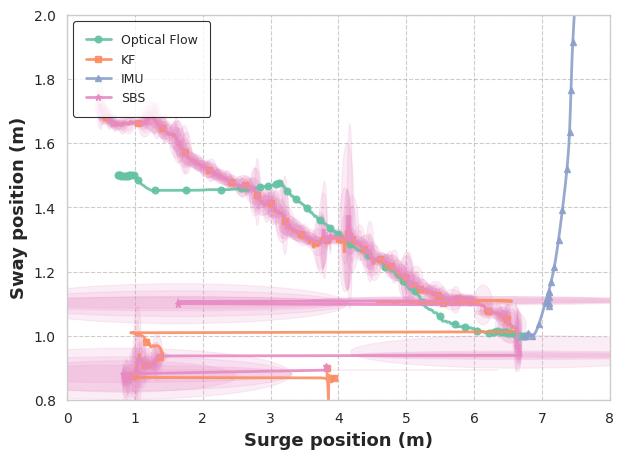

In [12]:

i=0
sns.set_style("whitegrid")
sns.set_context("paper")
palette = sns.color_palette("Set2")
markers = ['o', 's', '^',"*"]
sns.despine()

# --- Thesis-level font settings (bold legends, consistent sizes) ---
plt.rcParams.update({
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 12,
    'legend.edgecolor': 'black'
})
#plt.figure(figsize=(7, 5))
fig, ax = plt.subplots(1,1,figsize=(7, 5),sharey=True)
ax.plot(cumulative_displacement_y,cumulative_displacement_x,label="Optical Flow",color=palette[i],marker=markers[i],markevery=40,linewidth=2,alpha=0.9)



i=1
for case in imus[:]:
    print("i is "+str(i))
    print(case)
    df=pd.read_csv(case)



    if("IMU_only" in case):
        plt.plot(6.75-df["Pose_Y"],1+df["Pose_X"],label="IMU",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])

        gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
        gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
        gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
        rmse_val_imu_x=np.sqrt(((gt_interp_x -(6.75-df["Pose_Y"])) ** 2).mean())
        rmse_val_imu_y=np.sqrt(((gt_interp_y -(1-df["Pose_X"])) ** 2).mean())
        rmse_val_imu_z=np.sqrt(((gt_interp_z -(df["Pose_Z"]-df["Pose_Z"][0])) ** 2).mean())
        #print(df["Pose_Z"])
        print("IMU error _X",rmse_val_imu_x)
        print("IMU_x_SD",np.std(df["Pose_Y"]))
        print("IMU error _Y",rmse_val_imu_y)
        print("IMU_y_SD",np.std(df["Pose_X"]))
        print("IMU error _Z",rmse_val_imu_z)
        print("IMU_z_SD",np.std(df["Pose_Z"]))

        
        mae_val_imu_x = np.abs(gt_interp_x - (6.75 - df["Pose_Y"])).mean()
        mae_val_imu_y = np.abs(gt_interp_y - (1 - df["Pose_X"])).mean()
        mae_val_imu_z = np.abs(gt_interp_z - (df["Pose_Z"] - df["Pose_Z"][0])).mean()


        print("IMU error _X (MAE):", mae_val_imu_x)
        print("IMU error _Y (MAE):", mae_val_imu_y)
        print("IMU error _Z (MAE):", mae_val_imu_z)
        
    else:
        if("vel_only" in case):
            #ax.scatter(df["Pose_Y"],df["Pose_X"],label="KF with velocities",marker="+")
            print("ignore")
        elif("ptn_only" in case):
            #ax.scatter(df["Pose_Y"],df["Pose_X"],label="KF with positions",marker="+")
            print("ignore")    
        else:
            ax.plot(df["Pose_Y"],df["Pose_X"],label="KF",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])

            i+=1 
            #print(df["Pose_X"])
        gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
        gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
        gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
        rmse_val_imu_x=np.sqrt(((gt_interp_x[:]-(df["Pose_Y"][:])) ** 2).mean())
        print((df["Pose_Y"]))
        rmse_val_imu_y=np.sqrt(((gt_interp_y [:]-(df["Pose_X"][:])) ** 2).mean())
        rmse_val_imu_z=np.sqrt(((gt_interp_z[:] -(df["Pose_Z"][:]-df["Pose_Z"][0])) ** 2).mean())
        #print(df["Pose_Z"])
        print("KF error _X",rmse_val_imu_x)
        print("KF_x_SD",np.std(df["Pose_Y"]))
        print("KF error _Y",rmse_val_imu_y)
        print("KF_y_SD",np.std(df["Pose_X"]))
        print("KF error _Z",rmse_val_imu_z)
        print("KF_z_SD",np.std(df["Pose_Z"]))

        mae_val_imu_x = np.abs(gt_interp_y - (df["Pose_Y"])).mean()
        mae_val_imu_y = np.abs(gt_interp_x - (df["Pose_X"])).mean()
        mae_val_imu_z = np.abs(gt_interp_z - (df["Pose_Z"] - df["Pose_Z"][0])).mean()


        print("IMU error _X (MAE):", mae_val_imu_x)
        print("IMU error _Y (MAE):", mae_val_imu_y)
        print("IMU error _Z (MAE):", mae_val_imu_z)

    print(len(df))
    plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])
    plt.xlabel("X position (m)")
    plt.ylabel("Y position (m)")
    #plt.xlim(0,5)
    #plt.ylim(0,7)
    #i+=1
i+=1
for case in confidence_cases[:1]:
    #print(case)
    df=pd.read_csv(case)
    #plt.title("6th Nov-1205 run, Different localization methods")
    #plt.title("13th Nov- Different localization methods")

    
    ax.plot(df["Sonar_distance_2"]/1000,df["Sonar_distance_1"]/1000,label="SBS",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
    #i+=1
    print(len(df))
    plot_ellipses(ax,df)
    gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
    gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
    gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
    rmse_val_imu_x=np.sqrt(((gt_interp_x-df["Sonar_distance_2"]/1000).mean())**2)
    rmse_val_imu_y=np.sqrt(((gt_interp_y-df["Sonar_distance_1"]/1000).mean())**2)
    rmse_val_imu_z=np.sqrt(((gt_interp_z-(df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000).mean())**2)
    #print(df["Pose_Z"])
    print("SBS error _X",rmse_val_imu_x)
    print("SBS_x_SD",np.std(df["Sonar_distance_2"]/1000))
    print("SBS error _Y",rmse_val_imu_y)
    print("SBS_y_SD",np.std(df["Sonar_distance_1"]/1000))
    print("SBS error _Z",rmse_val_imu_z)
    print("SBS_z_SD",np.std(df["Sonar_distance_3"]/1000))


    mae_val_imu_x = np.abs(gt_interp_x - (df["Sonar_distance_2"]/1000)).mean()
    mae_val_imu_y = np.abs(gt_interp_y - (df["Sonar_distance_1"]/1000)).mean()
    mae_val_imu_z = np.abs(gt_interp_z - (df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000).mean()


    print("IMU error _X (MAE):", mae_val_imu_x)
    print("IMU error _Y (MAE):", mae_val_imu_y)
    print("IMU error _Z (MAE):", mae_val_imu_z)
    #plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])

plt.xlim(0,8)
plt.ylim(0.8,2)
plt.legend(
fontsize=9,
loc='upper left',
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
#plt.xlim([0,70])

plt.xlabel("Surge position (m)",fontsize=13, fontweight='bold')
plt.ylabel("Sway position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

In [110]:
i

3

/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_6thNov_1205_best_t2_.csv
1255
/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_6thNov_1205_best_t2_IMU_only.csv
1498
/home/saab/Desktop/2024_UWR/Analysis/confidence_case_6thNov_1205_best_t2_.csv
544


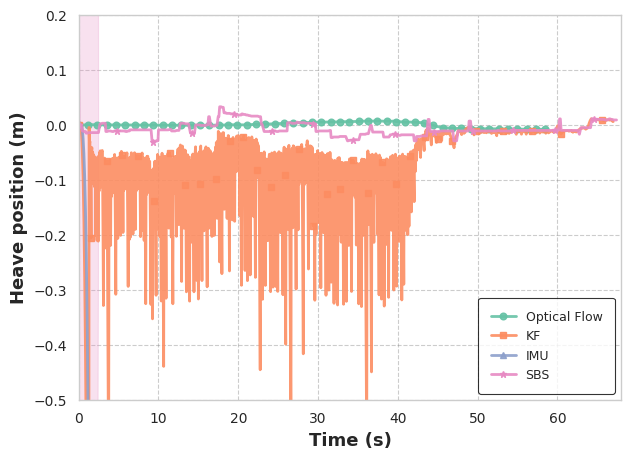

In [115]:
cumulative_displacement_zi=0
i=0
fig, ax = plt.subplots(1,1,figsize=(7, 5),sharey=True)
ax.plot(np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_z,label="Optical Flow",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])

i=1
for case in imus[:2]:
    print(case)
    df=pd.read_csv(case)


    if(i==1):
        ax.plot(df["Timestamp"]-df["Timestamp"][0],df["Pose_Z"]-df["Pose_Z"][0],label="KF",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
        #print(df["Pose_Z"])

    elif("imu_only" in case or "IMU_only" in case):
        ax.plot(df["Timestamp"]-df["Timestamp"][0],df["Pose_Z"]-df["Pose_Z"][0],label="IMU",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])




        
    print(len(df))
    plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])
    plt.xlabel("X position (m)")
    plt.ylabel("Y position (m)")
    #plt.xlim(0,5)
    #plt.ylim(0,7)
    i+=1
for case in confidence_cases[:1]:
    print(case)
    df=pd.read_csv(case)
    #plt.title("6th Nov-1205 run, Different localization methods")
    #plt.title("13th Nov- Different localization methods")

    
    ax.plot(df["Timestamp"]-df["Timestamp"][0],(df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000,label="SBS",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
    print(len(df))
    plot_ellipses(ax,df,s1="Sonar_distance_3",s2="Sonar_distance_3",c1="Confidence_3",rezero=True,c2="Confidence_3",scale=5)
    
plt.legend(
fontsize=9,
loc='lower right',
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
plt.ylim([-0.5,0.2])
plt.xlim([0,68])
plt.xlabel("Time (s)",fontsize=13, fontweight='bold')
plt.ylabel("Heave position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

In [112]:
for csv in cases[:]:
    print(csv)
    df=pd.read_csv(csv)
    gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
    gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
    gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
    rmse_val_sbs_x = np.sqrt(((gt_interp_y[:] - df["Sonar_distance_2"][:] / 1000) ** 2).mean())
    rmse_val_sbs_y = np.sqrt(((gt_interp_x - df["Sonar_distance_1"] / 1000) ** 2).mean())
    rmse_val_kf_y=np.sqrt(((gt_interp_x[:] - df["Pose_X"][:]) ** 2).mean())
    rmse_val_kf_x = np.sqrt(((gt_interp_y[:] - df["Pose_Y"][:]) ** 2).mean())
    rmse_val_kf_z=np.sqrt(((gt_interp_z[:] - (df["Pose_Z"][:]-df["Pose_Z"][0])) ** 2).mean())
    rmse_val_sbs_z=np.sqrt(((gt_interp_z[:] - (df["Sonar_distance_3"][:]-df["Sonar_distance_3"][0])/1000) ** 2).mean())
    #rmse_val_imu_z = np.sqrt(((gt_interp_z - (df["Sonar_distance_3"] - df["Sonar_distance_3"][0]) / 1000) ** 2).mean())

    print("KF error _X",rmse_val_kf_x,end=" ")
    print("KF_x_SD",np.std(df["Pose_Y"]))
    print("KF error _Y",rmse_val_kf_y,end=" ")
    print("KF_y_SD",np.std(df["Pose_X"]))
    print("KF error _Z",rmse_val_kf_z,end=" ")
    print("KF_z_SD",np.std(df["Pose_Z"]))
    print("SBS error _X",rmse_val_sbs_x,end=" ")
    print("SBS_x_SD",np.std(df["Sonar_distance_2"]/1000))
    print("SBS error _Y",rmse_val_sbs_y,end=" ")
    print("SBS_y_SD",np.std(df["Sonar_distance_1"]/1000))
    print("SBS error _Z",rmse_val_sbs_z,end=" ")
    print("SBS_z_SD",np.std(df["Sonar_distance_3"]/1000))

/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_best_t2_.csv
KF error _X 1.385130155980035 KF_x_SD 1.7305991039400634
KF error _Y 0.1062220252708005 KF_y_SD 0.2204535217070985
KF error _Z 0.0773595278138649 KF_z_SD 0.07538708427127731
SBS error _X 1.8690679187678354 SBS_x_SD 1.7989327268351838
SBS error _Y 0.10739136565129932 SBS_y_SD 0.22019598579598315
SBS error _Z 0.018362116264112993 SBS_z_SD 0.01320258201054448
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_t2_ptn_only.csv
KF error _X 1.409547350916638 KF_x_SD 1.7565975743309497
KF error _Y 0.09788321552237976 KF_y_SD 0.2270090323221798
KF error _Z 0.9392100362558081 KF_z_SD 0.6917914532639996
SBS error _X 1.760928696697179 SBS_x_SD 1.8136137412900237
SBS error _Y 0.11067918453670794 SBS_y_SD 0.23003678545158332
SBS error _Z 0.01742464946531031 SBS_z_SD 0.012451745692673964
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_t2_vel_only.csv
KF error _X 2.8108832225963853 KF_x_SD 1.88741358393543

/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_best_t2_.csv


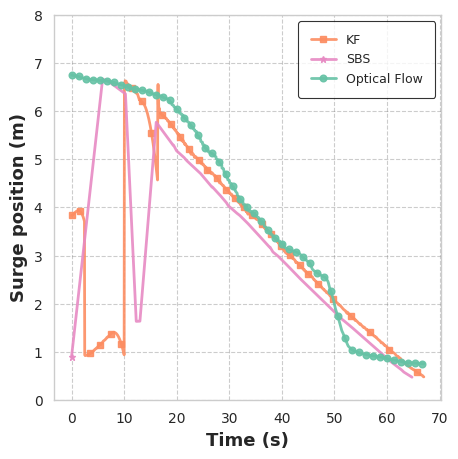

In [20]:
color_scheme=["tab:blue","tab:orange","tab:green"]
percentages=[10,20,30]
plt.figure(figsize=(5,5))
#plt.title("Expt_6thNov_1205_Best")
i=0
for case,imu in zip(cases[:1],imus[:1]):
    print(case)
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    times=np.linspace(0,df2['Timestamp'][len(df2)-1]-df2["Timestamp"][0],len(gt_df))
    
    #if(i==0 or i==7):
    plt.plot(np.array(df2['Timestamp']-df2["Timestamp"][0]),np.array(df2["Pose_Y"]),label="KF",color=palette[1],marker=markers[1],markevery=40,linewidth=2,alpha=0.9)
    
    
    #plt.legend()
    plt.ylim(0,8)
    #plt.show()
    i+=1
plt.plot(np.array(df1['Timestamp']-df1["Timestamp"][0]),np.array(df1["Sonar_distance_2"])/1000,label="SBS",color=palette[3],markevery=40,linewidth=2,alpha=0.9,marker=markers[3])
plt.plot(times,cumulative_displacement_y,label='Optical Flow',color=palette[0],markevery=40,linewidth=2,alpha=0.9,marker=markers[0])
plt.legend(fontsize=9,
loc='upper right',
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
#plt.
plt.xlabel("Time (s)",fontsize=13, fontweight='bold')
plt.ylabel("Surge position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

In [114]:
corrected_imus=[imus[0],imus[2],imus[3]]

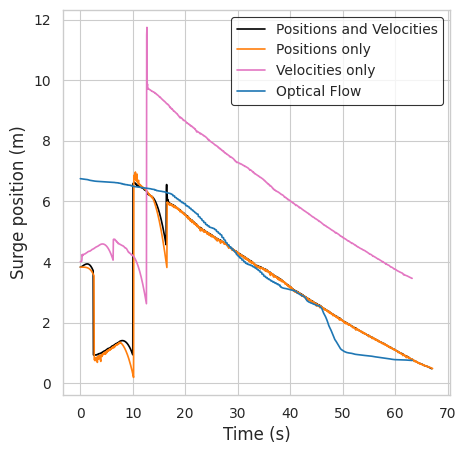

In [116]:
labels=["Positions and Velocities","Positions only","Velocities only"]
colors=["black","tab:orange","tab:pink"]
plt.figure(figsize=(5,5))
i=0
for case,imu,label in zip(cases[:],corrected_imus[:],labels[:]):
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    #plt.title(case)
    #plt.plot(np.array(df1["Timestamp"]-df1["Timestamp"][0]),np.array(df1["Sonar_distance_3"])/1000,label="SONAR")
    plt.plot(np.array(df2["Timestamp"]-df2["Timestamp"][0]),np.array(df2["Pose_Y"]),label=label,color=colors[i])
    
    
    plt.xlabel("Time (s)")
    plt.ylabel("Surge position (m)")
    #plt.ylim(0.5,1)
    #plt.show
    i+=1
plt.plot(np.linspace(0,np.array(df2["Timestamp"][len(df2)-1]-df2["Timestamp"][0]),len(cumulative_displacement_y)),cumulative_displacement_y,color="tab:blue",label="Optical Flow")
plt.legend()
plt.grid("on")

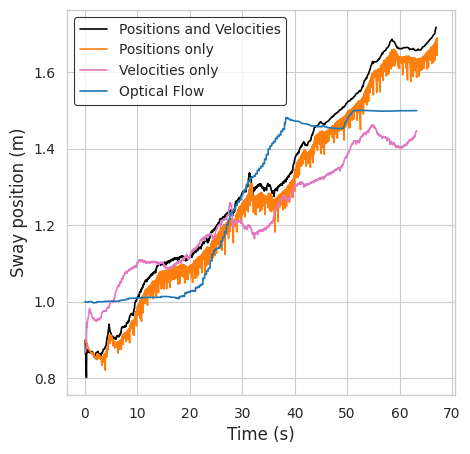

In [117]:
labels=["Positions and Velocities","Positions only","Velocities only"]
colors=["black","tab:orange","tab:pink"]
plt.figure(figsize=(5,5))
i=0
for case,imu,label in zip(cases[:],corrected_imus[:],labels[:]):
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    #plt.title(case)
    #plt.plot(np.array(df1["Timestamp"]-df1["Timestamp"][0]),np.array(df1["Sonar_distance_3"])/1000,label="SONAR")
    plt.plot(np.array(df2["Timestamp"]-df2["Timestamp"][0]),np.array(df2["Pose_X"]),label=label,color=colors[i])
    
    
    plt.xlabel("Time (s)")
    plt.ylabel("Sway position (m)")
    #plt.ylim(0.5,1)
    #plt.show
    i+=1
plt.plot(np.linspace(0,np.array(df2["Timestamp"][len(df2)-1]-df2["Timestamp"][0]),len(cumulative_displacement_x)),cumulative_displacement_x,color="tab:blue",label="Optical Flow")
plt.legend()
plt.grid("on")

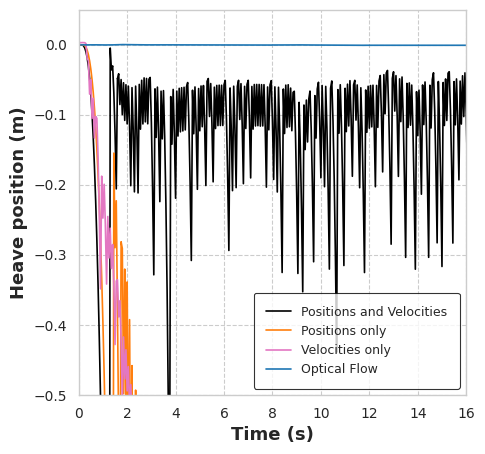

In [119]:
labels=["Positions and Velocities","Positions only","Velocities only"]
colors=["black","tab:orange","tab:pink"]
plt.figure(figsize=(5,5))
i=0
for case,imu,label in zip(cases[:],corrected_imus[:],labels[:]):
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    #plt.title(case)
    #plt.plot(np.array(df1["Timestamp"]-df1["Timestamp"][0]),np.array(df1["Sonar_distance_3"])/1000,label="SONAR")
    plt.plot(np.array(df2["Timestamp"]-df2["Timestamp"][0]),np.array(df2["Pose_Z"]-df2["Pose_Z"][0]),label=label,color=colors[i])
    
    
    plt.xlabel("Time (s)")
    plt.ylabel("Heave position (m)")
    #plt.ylim(0.5,1)
    #plt.show
    i+=1
plt.plot(np.linspace(0,np.array(df2["Timestamp"][len(df2)-1]-df2["Timestamp"][0]),len(cumulative_displacement_z)),cumulative_displacement_z,color="tab:blue",label="Optical Flow")
plt.legend(
fontsize=9,
loc='lower right',
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
plt.ylim([-0.5,0.05])
plt.xlim([0,16])
plt.xlabel("Time (s)",fontsize=13, fontweight='bold')
plt.ylabel("Heave position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

# 1302 (Thruster) dataset calculations

In [159]:
cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_case*1302*t2*"))
confidence_cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/confidence_case*1302*t2*"))
imus=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output*IMU*1302*t2*"))
gt=sorted(glob("/home/saab/Desktop/2024_UWR/Analysis/gt/13*/*corrected*1302.csv"))
gt

['/home/saab/Desktop/2024_UWR/Analysis/gt/13Nov/output_corrected_1302.csv']

In [71]:
#1302
gt_df=pd.read_csv(gt[0])
div_flows_mean=gt_df["Z"].to_numpy()
#displacements=np.sqrt(gt_df["X"].to_numpy()**2 + gt_df["Y"].to_numpy()**2)
displacements_x=gt_df["X"].to_numpy()
displacements_z=gt_df["Y"].to_numpy()
# Calculate cumulative displacement
displacements=np.sqrt(gt_df["X"].to_numpy()**2 + gt_df["Y"].to_numpy()**2)
cumulative_displacement_x = np.cumsum(div_flows_mean)
cumulative_displacement_y =np.cumsum(displacements)
cumulative_displacement_z =np.cumsum(displacements_z)*0.001
cumulative_displacement_x*=-0.1/abs(cumulative_displacement_x[0]-cumulative_displacement_x[cumulative_displacement_x.shape[0]-1])
cumulative_displacement_y*=6/abs(cumulative_displacement_y[0]-cumulative_displacement_y[cumulative_displacement_y.shape[0]-1])
cumulative_displacement_x+=1.28
cumulative_displacement_y=7.65-cumulative_displacement_y

/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_.csv
KF error _X 0.9617357800044569
KF_x_SD 1.8647556579076359
KF error _Y 0.09195658057108512
KF_y_SD 0.04681962416713861
KF error _Z 0.7984503763112996
KF_z_SD 0.1041024718390576
KF_var_x: 0.42061287768688044
KF_var_y: 0.006553035174275638
KF_var_z: 0.010615328310474405
339
/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_imu_only_.csv
IMU error _X 4.0106571497086065
IMU_x_var 2.6893572673708284
IMU error _Y 1.2884515744245764
IMU_y_var 0.9115646194848487
IMU error _Y 450.74918867998684
IMU_z_var 104278.72159709284
337
/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_13thNov_1302_t2_ptn_only.csv
ignore
KF error _X 0.9777687552225229
KF_x_SD 1.846859191538499
KF error _Y 0.08557680771695172
KF_y_SD 0.045822108313795795
KF error _Z 0.8561705155415683
KF_z_SD 0.8019181900663068
KF_var_x: 0.4221101839550528
KF_var_y: 0.005853574156287942
KF_var_z: 0.6392652740540062
330
/home/saab/Desktop/2024_UWR/Analysis/outpu

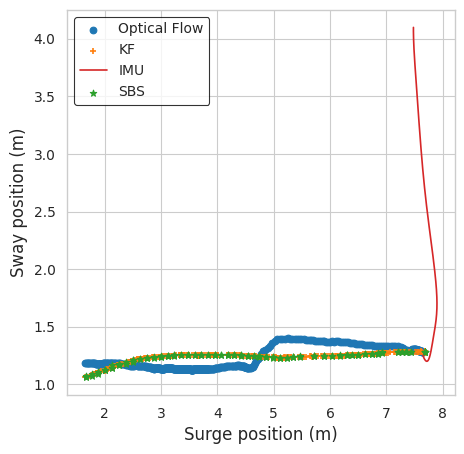

In [74]:
i=0
fig, ax = plt.subplots(1,1,figsize=(5, 5),sharey=True)
ax.scatter(cumulative_displacement_y,cumulative_displacement_x,label="Optical Flow",color="tab:blue")

i=1
for case in imus[:]:
    print(case)
    df=pd.read_csv(case)



    if("imu_only" in case):
        plt.plot(7.65-df["Pose_Y"],1.25-df["Pose_X"],label="IMU",color="tab:red")

        gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
        gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
        gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
        rmse_val_imu_x=np.sqrt(((gt_interp_y -(7.65-df["Pose_Y"])) ** 2).mean())
        rmse_val_imu_y=np.sqrt(((gt_interp_x -(1.25-df["Pose_X"])) ** 2).mean())
        rmse_val_imu_z=np.sqrt(((gt_interp_z -(df["Pose_Z"]-df["Pose_Z"][0])) ** 2).mean())
        #print(df["Pose_Z"])
        print("IMU error _X",rmse_val_imu_x)
        print("IMU_x_var",np.var(gt_interp_y -(7.65-df["Pose_Y"])))
        print("IMU error _Y",rmse_val_imu_y)
        print("IMU_y_var",np.var(gt_interp_x -(1.25-df["Pose_X"])))
        print("IMU error _Y",rmse_val_imu_z)
        print("IMU_z_var",np.var(gt_interp_z -(df["Pose_Z"]-df["Pose_Z"][0])))
        
    

    else:
        if("vel_only" in case or "ptn_only" in case):
            print("ignore")
            #ax.scatter(df["Pose_Y"],df["Pose_X"],label="KF with velocities",marker="+")
        else:
            ax.scatter(df["Pose_Y"],df["Pose_X"],label="KF",marker="+",color="tab:orange")
            #print("ignore")
        
        gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
        gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
        gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
        rmse_val_imu_x=np.sqrt(((gt_interp_y -(df["Pose_Y"])) ** 2).mean())
        rmse_val_imu_y=np.sqrt(((gt_interp_x -(df["Pose_X"])) ** 2).mean())
        rmse_val_imu_z=np.sqrt(((gt_interp_z -(df["Pose_Z"])) ** 2).mean())
        #print(df["Pose_Z"])
        print("KF error _X",rmse_val_imu_x)
        print("KF_x_SD",np.std(df["Pose_Y"]))
        print("KF error _Y",rmse_val_imu_y)
        print("KF_y_SD",np.std(df["Pose_X"]))
        print("KF error _Z",rmse_val_imu_z)
        print("KF_z_SD",np.std(df["Pose_Z"]))
        mae_val_imu_x = np.var(gt_interp_y - (df["Pose_Y"]))
        mae_val_imu_y = np.var(gt_interp_x - (df["Pose_X"]))
        mae_val_imu_z = np.var(gt_interp_z - (df["Pose_Z"] - df["Pose_Z"][0]))


        print("KF_var_x:", mae_val_imu_x)
        print("KF_var_y:", mae_val_imu_y)
        print("KF_var_z:", mae_val_imu_z)

        
    print(len(df))
    plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])
    plt.xlabel("X position (m)")
    plt.ylabel("Y position (m)")
    #plt.xlim(0,5)
    #plt.ylim(0,7)
    i+=1
for case in confidence_cases[:1]:
    print(case)
    df=pd.read_csv(case)
    #plt.title("6th Nov-1205 run, Different localization methods")
    #plt.title("13th Nov- Different localization methods")

    
    ax.scatter(df["Sonar_distance_2"]/1000,df["Sonar_distance_1"]/1000,label="SBS",color="tab:green",marker="*")
    print(len(df))
    #plot_ellipses(ax,df)
    gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
    gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
    gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
    rmse_val_imu_x=np.sqrt(((gt_interp_y-df["Sonar_distance_2"]/1000).mean())**2)
    rmse_val_imu_y=np.sqrt(((gt_interp_x-df["Sonar_distance_1"]/1000).mean())**2)
    rmse_val_imu_z=np.sqrt(((gt_interp_z-(df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000).mean())**2)
    #print(df["Pose_Z"])
    print("SBS error _X",rmse_val_imu_x)
    print("SBS_x_var",np.var(gt_interp_y-df["Sonar_distance_2"]/1000))
    print("SBS error _Y",rmse_val_imu_y)
    print("SBS_y_var",np.var(gt_interp_x-df["Sonar_distance_1"]/1000))
    print("SBS error _Z",rmse_val_imu_z)
    print("SBS_z_var",np.var(gt_interp_z-(df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000))
    plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])
    plt.xlabel("Surge position (m)")
    plt.ylabel("Sway position (m)")
    #plt.xlim(1,8)
    #plt.ylim(0,2)
    plt.grid("on")

i is 1
/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_.csv
0      7.685000
1      7.685000
2      7.685000
3      7.685000
4      7.685000
         ...   
334    1.780482
335    1.763349
336    1.735197
337    1.688453
338    1.656704
Name: Pose_Y, Length: 339, dtype: float64
KF error _X 0.9617357800044569
KF_x_SD 1.8647556579076359
KF error _Y 0.09195658057108512
KF_y_SD 0.04681962416713861
KF error _Z 0.1402965771747627
KF_z_SD 0.1041024718390576
IMU error _X (MAE): 3.5783339585842806
IMU error _Y (MAE): 2.8245539206315824
IMU error _Z (MAE): 0.09522500331572452
339
i is 2
/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_imu_only_.csv
IMU error _X 3.2104935900422147
IMU_x_SD 0.11807056276486816
IMU error _Y 1.135788540211113
IMU_y_SD 0.9213707530803974
IMU error _Z 450.74918867998684
IMU_z_SD 322.9257198455405
IMU error _X (MAE): 2.9242058890789493
IMU error _Y (MAE): 0.8260765333252081
IMU error _Z (MAE): 314.4775182720913
337
i is 2
/home/saab/Desktop/2024

<Figure size 640x480 with 0 Axes>

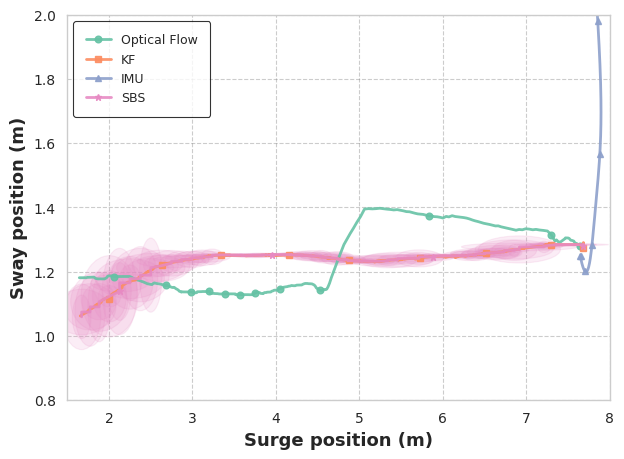

In [33]:

i=0
sns.set_style("whitegrid")
sns.set_context("paper")
palette = sns.color_palette("Set2")
markers = ['o', 's', '^',"*"]
sns.despine()

# --- Thesis-level font settings (bold legends, consistent sizes) ---
plt.rcParams.update({
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 12,
    'legend.edgecolor': 'black'
})
#plt.figure(figsize=(7, 5))
fig, ax = plt.subplots(1,1,figsize=(7, 5),sharey=True)
ax.plot(cumulative_displacement_y,cumulative_displacement_x,label="Optical Flow",color=palette[i],marker=markers[i],markevery=40,linewidth=2,alpha=0.9)



i=1
for case in imus[:]:
    print("i is "+str(i))
    print(case)
    df=pd.read_csv(case)



    if("imu_only" in case):
        plt.plot(7.65-df["Pose_Y"],1.25-df["Pose_X"],label="IMU",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])

        gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
        gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
        gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
        rmse_val_imu_x=np.sqrt(((gt_interp_x -(6.75-df["Pose_Y"])) ** 2).mean())
        rmse_val_imu_y=np.sqrt(((gt_interp_y -(1-df["Pose_X"])) ** 2).mean())
        rmse_val_imu_z=np.sqrt(((gt_interp_z -(df["Pose_Z"]-df["Pose_Z"][0])) ** 2).mean())
        #print(df["Pose_Z"])
        print("IMU error _X",rmse_val_imu_x)
        print("IMU_x_SD",np.std(df["Pose_Y"]))
        print("IMU error _Y",rmse_val_imu_y)
        print("IMU_y_SD",np.std(df["Pose_X"]))
        print("IMU error _Z",rmse_val_imu_z)
        print("IMU_z_SD",np.std(df["Pose_Z"]))

        
        mae_val_imu_x = np.abs(gt_interp_x - (6.75 - df["Pose_Y"])).mean()
        mae_val_imu_y = np.abs(gt_interp_y - (1 - df["Pose_X"])).mean()
        mae_val_imu_z = np.abs(gt_interp_z - (df["Pose_Z"] - df["Pose_Z"][0])).mean()


        print("IMU error _X (MAE):", mae_val_imu_x)
        print("IMU error _Y (MAE):", mae_val_imu_y)
        print("IMU error _Z (MAE):", mae_val_imu_z)
        
    else:
        if("vel_only" in case):
            #ax.scatter(df["Pose_Y"],df["Pose_X"],label="KF with velocities",marker="+")
            print("ignore")
        elif("ptn_only" in case):
            #ax.scatter(df["Pose_Y"],df["Pose_X"],label="KF with positions",marker="+")
            print("ignore")    
        else:
            ax.plot(df["Pose_Y"],df["Pose_X"],label="KF",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])

            i+=1 
            #print(df["Pose_X"])
        gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
        gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
        gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
        rmse_val_imu_x=np.sqrt(((gt_interp_x[:]-(df["Pose_Y"][:])) ** 2).mean())
        print((df["Pose_Y"]))
        rmse_val_imu_y=np.sqrt(((gt_interp_y [:]-(df["Pose_X"][:])) ** 2).mean())
        rmse_val_imu_z=np.sqrt(((gt_interp_z[:] -(df["Pose_Z"][:]-df["Pose_Z"][0])) ** 2).mean())
        #print(df["Pose_Z"])
        print("KF error _X",rmse_val_imu_x)
        print("KF_x_SD",np.std(df["Pose_Y"]))
        print("KF error _Y",rmse_val_imu_y)
        print("KF_y_SD",np.std(df["Pose_X"]))
        print("KF error _Z",rmse_val_imu_z)
        print("KF_z_SD",np.std(df["Pose_Z"]))

        mae_val_imu_x = np.abs(gt_interp_y - (df["Pose_Y"])).mean()
        mae_val_imu_y = np.abs(gt_interp_x - (df["Pose_X"])).mean()
        mae_val_imu_z = np.abs(gt_interp_z - (df["Pose_Z"] - df["Pose_Z"][0])).mean()


        print("IMU error _X (MAE):", mae_val_imu_x)
        print("IMU error _Y (MAE):", mae_val_imu_y)
        print("IMU error _Z (MAE):", mae_val_imu_z)

    print(len(df))
    plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])
    plt.xlabel("X position (m)")
    plt.ylabel("Y position (m)")
    #plt.xlim(0,5)
    #plt.ylim(0,7)
    #i+=1
i+=1
for case in confidence_cases[:1]:
    #print(case)
    df=pd.read_csv(case)
    #plt.title("6th Nov-1205 run, Different localization methods")
    #plt.title("13th Nov- Different localization methods")

    
    ax.plot(df["Sonar_distance_2"]/1000,df["Sonar_distance_1"]/1000,label="SBS",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
    #i+=1
    print(len(df))
    plot_ellipses(ax,df)
    gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
    gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
    gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
    rmse_val_imu_x=np.sqrt(((gt_interp_x-df["Sonar_distance_2"]/1000).mean())**2)
    rmse_val_imu_y=np.sqrt(((gt_interp_y-df["Sonar_distance_1"]/1000).mean())**2)
    rmse_val_imu_z=np.sqrt(((gt_interp_z-(df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000).mean())**2)
    #print(df["Pose_Z"])
    print("SBS error _X",rmse_val_imu_x)
    print("SBS_x_SD",np.std(df["Sonar_distance_2"]/1000))
    print("SBS error _Y",rmse_val_imu_y)
    print("SBS_y_SD",np.std(df["Sonar_distance_1"]/1000))
    print("SBS error _Z",rmse_val_imu_z)
    print("SBS_z_SD",np.std(df["Sonar_distance_3"]/1000))


    mae_val_imu_x = np.abs(gt_interp_x - (df["Sonar_distance_2"]/1000)).mean()
    mae_val_imu_y = np.abs(gt_interp_y - (df["Sonar_distance_1"]/1000)).mean()
    mae_val_imu_z = np.abs(gt_interp_z - (df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000).mean()


    print("IMU error _X (MAE):", mae_val_imu_x)
    print("IMU error _Y (MAE):", mae_val_imu_y)
    print("IMU error _Z (MAE):", mae_val_imu_z)
    #plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])

plt.xlim(1.5,8)
plt.ylim(0.8,2)
plt.legend(
fontsize=9,
loc='upper left',
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
#plt.xlim([0,70])

plt.xlabel("Surge position (m)",fontsize=13, fontweight='bold')
plt.ylabel("Sway position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_.csv
339
/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_imu_only_.csv
337
/home/saab/Desktop/2024_UWR/Analysis/confidence_case_1302_t2_.csv
132


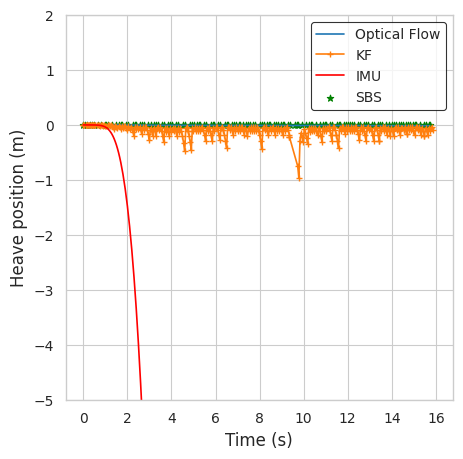

In [25]:
cumulative_displacement_zi=0
fig, ax = plt.subplots(1,1,figsize=(5, 5),sharey=True)
ax.plot(np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_z,label="Optical Flow")

i=1
for case in imus[:2]:
    print(case)
    df=pd.read_csv(case)


    if(i==1):
        ax.plot(df["Timestamp"]-df["Timestamp"][0],df["Pose_Z"]-df["Pose_Z"][0],label="KF",marker="+")
        #print(df["Pose_Z"])

    elif("imu_only" in case or "IMU_only" in case):
        ax.plot(df["Timestamp"]-df["Timestamp"][0],df["Pose_Z"]-df["Pose_Z"][0],label="IMU",color="red")




        
    print(len(df))
    plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])
    plt.xlabel("X position (m)")
    plt.ylabel("Y position (m)")
    #plt.xlim(0,5)
    #plt.ylim(0,7)
    i+=1
for case in confidence_cases[:1]:
    print(case)
    df=pd.read_csv(case)
    #plt.title("6th Nov-1205 run, Different localization methods")
    #plt.title("13th Nov- Different localization methods")

    
    ax.scatter(df["Timestamp"]-df["Timestamp"][0],(df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000,label="SBS",color="green",marker="*")
    print(len(df))
    plot_ellipses(ax,df,s1="Sonar_distance_3",s2="Sonar_distance_3",c1="Confidence_3",rezero=True,c2="Confidence_3",scale=5)
    
    plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])
    plt.xlabel("Time (s)")
    plt.ylabel("Heave position (m)")
    #plt.xlim(1,8)
    plt.ylim(-5,2)
    plt.grid("on")

/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_.csv
339
/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_imu_only_.csv
337
/home/saab/Desktop/2024_UWR/Analysis/confidence_case_1302_t2_.csv
132


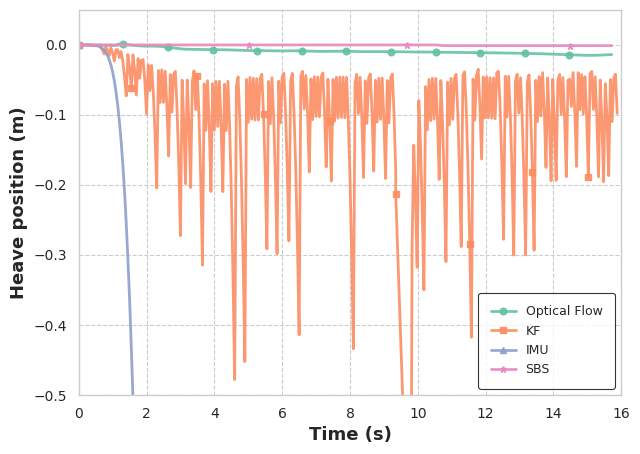

In [26]:
cumulative_displacement_zi=0
i=0
fig, ax = plt.subplots(1,1,figsize=(7, 5),sharey=True)
ax.plot(np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_z,label="Optical Flow",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])

i=1
for case in imus[:2]:
    print(case)
    df=pd.read_csv(case)


    if(i==1):
        ax.plot(df["Timestamp"]-df["Timestamp"][0],df["Pose_Z"]-df["Pose_Z"][0],label="KF",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
        #print(df["Pose_Z"])

    elif("imu_only" in case or "IMU_only" in case):
        ax.plot(df["Timestamp"]-df["Timestamp"][0],df["Pose_Z"]-df["Pose_Z"][0],label="IMU",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])




        
    print(len(df))
    plt.legend()
    #plt.legend(["Q=1, R=1","Q=0.0001, R=1","Q=0.0001, R=100","Q=0.01, R=1"])
    plt.xlabel("X position (m)")
    plt.ylabel("Y position (m)")
    #plt.xlim(0,5)
    #plt.ylim(0,7)
    i+=1
for case in confidence_cases[:1]:
    print(case)
    df=pd.read_csv(case)
    #plt.title("6th Nov-1205 run, Different localization methods")
    #plt.title("13th Nov- Different localization methods")

    
    ax.plot(df["Timestamp"]-df["Timestamp"][0],(df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000,label="SBS",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
    print(len(df))
    plot_ellipses(ax,df,s1="Sonar_distance_3",s2="Sonar_distance_3",c1="Confidence_3",rezero=True,c2="Confidence_3",scale=5)
    
plt.legend(
fontsize=9,
loc='lower right',
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
plt.ylim([-0.5,0.05])
plt.xlim([0,16])
plt.xlabel("Time (s)",fontsize=13, fontweight='bold')
plt.ylabel("Heave position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

In [72]:
for csv in cases[:]:
    print(csv)
    df=pd.read_csv(csv)
    gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
    gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
    gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)
    rmse_val_sbs_x = np.sqrt(((gt_interp_y[:] - df["Sonar_distance_2"][:] / 1000) ** 2).mean())
    rmse_val_sbs_y = np.sqrt(((gt_interp_x - df["Sonar_distance_1"] / 1000) ** 2).mean())
    rmse_val_kf_y=np.sqrt(((gt_interp_x[:] - df["Pose_X"][:]) ** 2).mean())
    rmse_val_kf_x = np.sqrt(((gt_interp_y[:] - df["Pose_Y"][:]) ** 2).mean())
    rmse_val_kf_z=np.sqrt(((gt_interp_z[:] - (df["Pose_Z"][:]-df["Pose_Z"][0])) ** 2).mean())
    rmse_val_sbs_z=np.sqrt(((gt_interp_z[:] - (df["Sonar_distance_3"][:]-df["Sonar_distance_3"][0])/1000) ** 2).mean())
    #rmse_val_imu_z = np.sqrt(((gt_interp_z - (df["Sonar_distance_3"] - df["Sonar_distance_3"][0]) / 1000) ** 2).mean())

    print("KF error _X",rmse_val_kf_x,end=" ")
    print("KF_x_SD",np.std(df["Pose_Y"]))
    print("KF error _Y",rmse_val_kf_y,end=" ")
    print("KF_y_SD",np.std(df["Pose_X"]))
    print("KF error _Z",rmse_val_kf_z,end=" ")
    print("KF_z_SD",np.std(df["Pose_Z"]))
    print("SBS error _X",rmse_val_sbs_x,end=" ")
    print("SBS_x_SD",np.std(df["Sonar_distance_2"]/1000))
    print("SBS error _Y",rmse_val_sbs_y,end=" ")
    print("SBS_y_SD",np.std(df["Sonar_distance_1"]/1000))
    print("SBS error _Z",rmse_val_sbs_z,end=" ")
    print("SBS_z_SD",np.std(df["Sonar_distance_3"]/1000))

/home/saab/Desktop/2024_UWR/Analysis/output_case_1302_t2_.csv
KF error _X 0.9660986114581697 KF_x_SD 1.6203400915497335
KF error _Y 0.08978109264474414 KF_y_SD 0.027853035441474248
KF error _Z 0.061822966976906944 KF_z_SD 0.05741679828744036
SBS error _X 0.8961747705843323 SBS_x_SD 1.6140854035645078
SBS error _Y 0.09035664556165343 SBS_y_SD 0.030899999999999993
SBS error _Z 0.008993499557411551 SBS_z_SD 0.00040000000000000034
/home/saab/Desktop/2024_UWR/Analysis/output_case_13thNov_1302_t2_ptn_only.csv
KF error _X 0.9615751301844795 KF_x_SD 1.6277646678771036
KF error _Y 0.07986517229611453 KF_y_SD 0.02999664997606889
KF error _Z 2.0285607295074737 KF_z_SD 1.575903801849414
SBS error _X 0.8961582744987778 SBS_x_SD 1.6140854035645078
SBS error _Y 0.09035568716186727 SBS_y_SD 0.030899999999999993
SBS error _Z 0.008993133961418284 SBS_z_SD 0.00040000000000000034
/home/saab/Desktop/2024_UWR/Analysis/output_case_13thNov_1302_t2_vel_only.csv
KF error _X 0.7389310915319277 KF_x_SD 1.79282342

In [28]:
imus

['/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_.csv',
 '/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_imu_only_.csv',
 '/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_13thNov_1302_t2_ptn_only.csv',
 '/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_13thNov_1302_t2_vel_only.csv']

In [29]:
corrected_imus=[imus[0],imus[2],imus[3]]

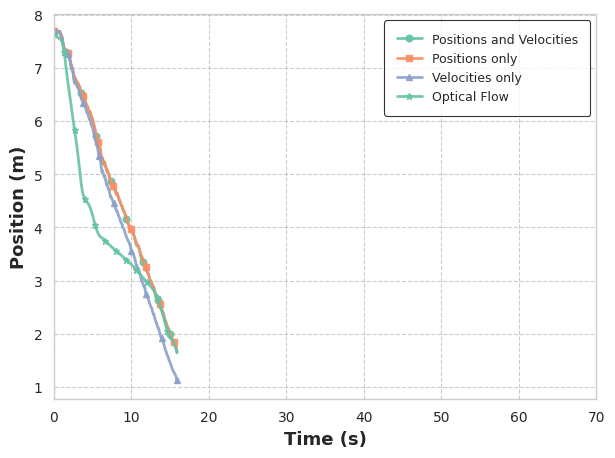

In [30]:
labels=["Positions and Velocities","Positions only","Velocities only"]
#colors=["black","tab:orange","tab:pink"]
i=1
plt.figure(figsize=(7,5))
i=0
for case,imu,label in zip(cases[:],corrected_imus[:],labels[:]):
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    #plt.title(case)
    #plt.plot(np.array(df1["Timestamp"]-df1["Timestamp"][0]),np.array(df1["Sonar_distance_3"])/1000,label="SONAR")
    plt.plot(np.array(df2["Timestamp"]-df2["Timestamp"][0]),np.array(df2["Pose_Y"]),label=label,markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
    
    
    plt.xlabel("Time (s)")
    plt.ylabel("Surge position (m)")
    #plt.ylim(0.5,1)
    #plt.show
    i+=1
plt.plot(np.linspace(0,np.array(df2["Timestamp"][len(df2)-1]-df2["Timestamp"][0]),len(cumulative_displacement_y)),cumulative_displacement_y,color=palette[0],label="Optical Flow",markevery=40,linewidth=2,alpha=0.9,marker=markers[i])
plt.legend(
fontsize=9,
loc='upper right',
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
#plt.ylim([-0.5,0.05])
plt.xlim([0,70])
plt.xlabel("Time (s)",fontsize=13, fontweight='bold')
plt.ylabel("Position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

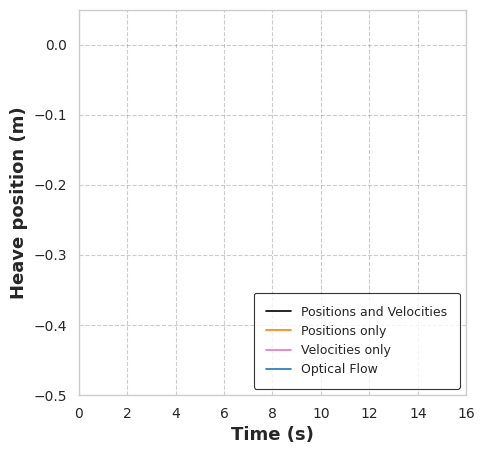

In [31]:
labels=["Positions and Velocities","Positions only","Velocities only"]
colors=["black","tab:orange","tab:pink"]
plt.figure(figsize=(5,5))
i=0
for case,imu,label in zip(cases[:],corrected_imus[:],labels[:]):
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    #plt.title(case)
    #plt.plot(np.array(df1["Timestamp"]-df1["Timestamp"][0]),np.array(df1["Sonar_distance_3"])/1000,label="SONAR")
    plt.plot(np.array(df2["Timestamp"]-df2["Timestamp"][0]),np.array(df2["Pose_X"]),label=label,color=colors[i])
    
    
    plt.xlabel("Time (s)")
    plt.ylabel("Sway position (m)")
    #plt.ylim(0.5,1)
    #plt.show
    i+=1
plt.plot(np.linspace(0,np.array(df2["Timestamp"][len(df2)-1]-df2["Timestamp"][0]),len(cumulative_displacement_x)),cumulative_displacement_x,color="tab:blue",label="Optical Flow")
plt.legend(
fontsize=9,
loc='lower right',
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
plt.ylim([-0.5,0.05])
plt.xlim([0,16])
plt.xlabel("Time (s)",fontsize=13, fontweight='bold')
plt.ylabel("Heave position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

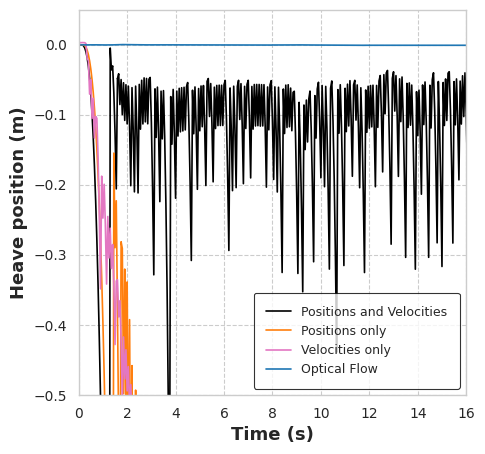

In [121]:
labels=["Positions and Velocities","Positions only","Velocities only"]
colors=["black","tab:orange","tab:pink"]
plt.figure(figsize=(5,5))
i=0
for case,imu,label in zip(cases[:],corrected_imus[:],labels[:]):
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    #plt.title(case)
    #plt.plot(np.array(df1["Timestamp"]-df1["Timestamp"][0]),np.array(df1["Sonar_distance_3"])/1000,label="SONAR")
    plt.plot(np.array(df2["Timestamp"]-df2["Timestamp"][0]),np.array(df2["Pose_Z"]-df2["Pose_Z"][0]),label=label,color=colors[i])
    
    
    plt.xlabel("Time (s)")
    plt.ylabel("Heave position (m)")
    #plt.ylim(0.5,1)
    #plt.show
    i+=1
plt.plot(np.linspace(0,np.array(df2["Timestamp"][len(df2)-1]-df2["Timestamp"][0]),len(cumulative_displacement_z)),cumulative_displacement_z,color="tab:blue",label="Optical Flow")
plt.legend(
fontsize=9,
loc='lower right',
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
plt.ylim([-0.5,0.05])
plt.xlim([0,16])
plt.xlabel("Time (s)",fontsize=13, fontweight='bold')
plt.ylabel("Heave position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

## Checking effects of different parameters on KF

In [61]:
#Expected Difference
cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_case*1205*t0*.csv"))
confidence_cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/confidence_case*1205*t0*.csv"))
imus=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_IMU*1205*t0*.csv"))

/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_t0_001.csv
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_t0_01.csv
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_t0_1.csv


<Figure size 640x480 with 0 Axes>

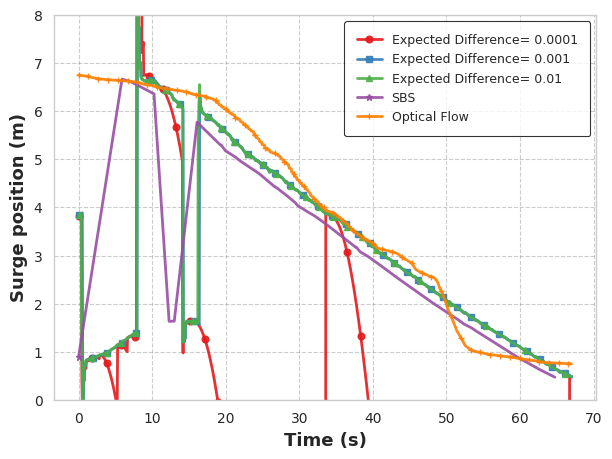

In [62]:

sns.set_style("whitegrid")
sns.set_context("paper")
palette = sns.color_palette("Set1")
markers = ['o', 's', '^',"*","+"]
sns.despine()

# --- Thesis-level font settings (bold legends, consistent sizes) ---
plt.rcParams.update({
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 12,
    'legend.edgecolor': 'black'
})
#plt.figure(figsize=(7, 5))
fig, ax = plt.subplots(1,1,figsize=(7, 5),sharey=True)
i=0
#plt.title("Effect of differences on KF")
for case,imu in zip(cases[:],imus[:]):
    print(case)
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    times=np.linspace(0,df2['Timestamp'][len(df2)-1]-df2["Timestamp"][0],len(gt_df))
    
    #if(i==0 or i==7):
    plt.plot(np.array(df2['Timestamp']-df2["Timestamp"][0]),np.array(df2["Pose_Y"]),label="Expected Difference= "+str(1/np.power(10,4-i)),markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
    
    
    #plt.legend()
    plt.ylim(0,8)
    #plt.show()
    i+=1
plt.plot(np.array(df1['Timestamp']-df1["Timestamp"][0]),np.array(df1["Sonar_distance_2"])/1000,label="SBS",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
plt.plot(times,cumulative_displacement_y,label='Optical Flow',markevery=40,linewidth=2,alpha=0.9,marker=markers[4],color=palette[4])
plt.legend(
fontsize=9,
loc='upper right',
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
plt.xlabel("Time (s)",fontsize=13, fontweight='bold')
plt.ylabel("Surge position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

In [44]:
#Persistence
cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_case*1205*persist*.csv"))
confidence_cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/confidence_case*persist*.csv"))
imus=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_IMU*1205*persist*.csv"))

/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_persist_10_.csv
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_persist_20_.csv
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_persist_30_.csv


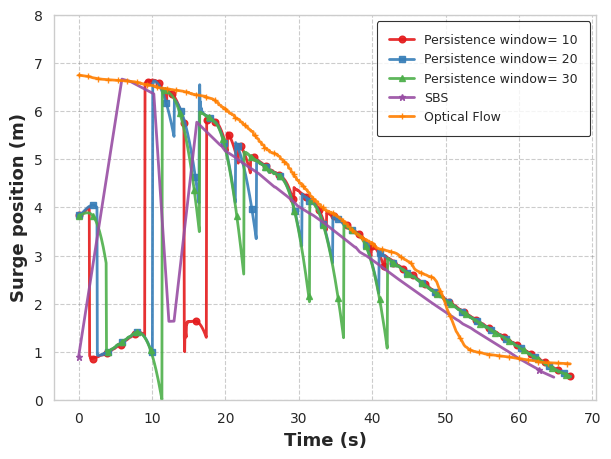

In [45]:

#plt.figure(figsize=(7, 5))
fig, ax = plt.subplots(1,1,figsize=(7, 5),sharey=True)
percentages=[10,20,30]
#plt.title("Effect of persistence windows on KF")
i=0
for case,imu in zip(cases[:],imus[:]):
    print(case)
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    times=np.linspace(0,df2['Timestamp'][len(df2)-1]-df2["Timestamp"][0],len(gt_df))
    
    #if(i==0 or i==7):
    plt.plot(np.array(df2['Timestamp']-df2["Timestamp"][0]),np.array(df2["Pose_Y"]),label="Persistence window= "+str(percentages[i]),markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
    
    
    #plt.legend()
    plt.ylim(0,8)
    #plt.show()
    i+=1
plt.plot(np.array(df1['Timestamp']-df1["Timestamp"][0]),np.array(df1["Sonar_distance_2"])/1000,label="SBS",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
plt.plot(times,cumulative_displacement_y,label='Optical Flow',markevery=40,linewidth=2,alpha=0.9,marker=markers[4],color=palette[4])
plt.legend(
fontsize=9,
loc='upper right',
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
plt.xlabel("Time (s)",fontsize=13, fontweight='bold')
plt.ylabel("Surge position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

In [46]:
#Tolerance Percentages
cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_case*1205*tp*.csv"))
confidence_cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/confidence_case*1205*tp*.csv"))
imus=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_IMU*1205*tp*.csv"))

/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_t_50_tp.csv
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_t_75_tp.csv
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_t_90_tp.csv


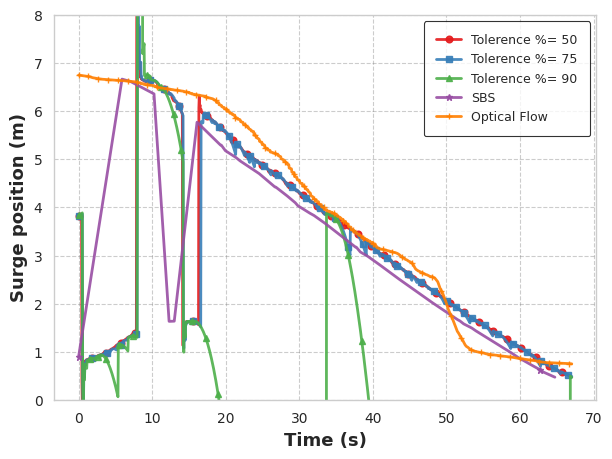

In [47]:
percentages=[50,75,90]
# --- Thesis-level font settings (bold legends, consistent sizes) ---
plt.rcParams.update({
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 12,
    'legend.edgecolor': 'black'
})
#plt.figure(figsize=(7, 5))
fig, ax = plt.subplots(1,1,figsize=(7, 5),sharey=True)
#plt.title("Effect of tolerance percentages on KF")
i=0
for case,imu in zip(cases[:],imus[:]):
    print(case)
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    times=np.linspace(0,df2['Timestamp'][len(df2)-1]-df2["Timestamp"][0],len(gt_df))
    
    #if(i==0 or i==7):
    plt.plot(np.array(df2['Timestamp']-df2["Timestamp"][0]),np.array(df2["Pose_Y"]),label="Tolerence %= "+str(percentages[i]),markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
    
    
    #plt.legend()
    plt.ylim(0,8)
    #plt.show()
    i+=1
plt.plot(np.array(df1['Timestamp']-df1["Timestamp"][0]),np.array(df1["Sonar_distance_2"])/1000,label="SBS",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
plt.plot(times,cumulative_displacement_y,label='Optical Flow',markevery=40,linewidth=2,alpha=0.9,marker=markers[4],color=palette[4])
plt.legend(
fontsize=9,
loc='upper right',
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
plt.xlabel("Time (s)",fontsize=13, fontweight='bold')
plt.ylabel("Surge position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

In [53]:
#R
cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_case*1205*R*.csv"))
confidence_cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/confidence_case*1205*R*.csv"))
imus=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_IMU*1205*R*.csv"))

/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_R_0.001_.csv
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_R_0.01_.csv
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_R_0.1_.csv


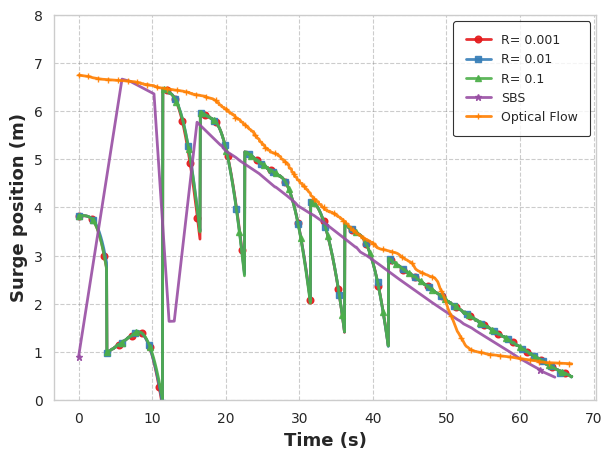

In [54]:
#R values


i=0


# --- Thesis-level font settings (bold legends, consistent sizes) ---
plt.rcParams.update({
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 12,
    'legend.edgecolor': 'black'
})
#plt.figure(figsize=(7, 5))
fig, ax = plt.subplots(1,1,figsize=(7, 5),sharey=True)
color_scheme=["black","tab:orange","tab:pink"]
percentages=[0.001,0.01,0.1]
#plt.title("Effect of Q on KF")
i=0
for case,imu in zip(cases[:],imus[:]):
    print(case)
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    times=np.linspace(0,df2['Timestamp'][len(df2)-1]-df2["Timestamp"][0],len(gt_df))
    
    #if(i==0 or i==7):
    plt.plot(np.array(df2['Timestamp']-df2["Timestamp"][0]),np.array(df2["Pose_Y"]),label="R= "+str(percentages[i]),markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
    
    
    #plt.legend()
    plt.ylim(0,8)
    #plt.show()
    i+=1
plt.plot(np.array(df1['Timestamp']-df1["Timestamp"][0]),np.array(df1["Sonar_distance_2"])/1000,label="SBS",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
plt.plot(times,cumulative_displacement_y,label='Optical Flow',markevery=40,linewidth=2,alpha=0.9,marker=markers[4],color=palette[4])
plt.legend(
fontsize=9,
loc='upper right',
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
plt.xlabel("Time (s)",fontsize=13, fontweight='bold')
plt.ylabel("Surge position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

In [55]:
#Q


cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_case*1205*Q*.csv"))
confidence_cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/confidence_case*1205*Q*.csv"))
imus=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/output_IMU*1205*Q*.csv"))

/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_Q_0.001_.csv
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_Q_0.01_.csv
/home/saab/Desktop/2024_UWR/Analysis/output_case_6thNov_1205_Q_0.1_.csv


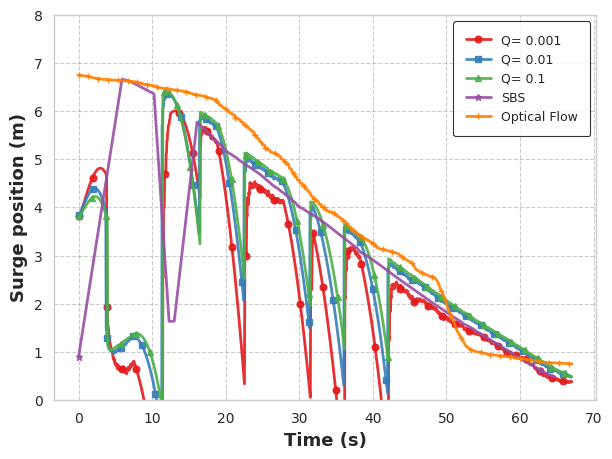

In [56]:
#Q values


i=0


# --- Thesis-level font settings (bold legends, consistent sizes) ---
plt.rcParams.update({
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 12,
    'legend.edgecolor': 'black'
})
#plt.figure(figsize=(7, 5))
fig, ax = plt.subplots(1,1,figsize=(7, 5),sharey=True)

percentages=[0.001,0.01,0.1]
#plt.title("Effect of Q on KF")
i=0
for case,imu in zip(cases[:],imus[:]):
    print(case)
    df1=pd.read_csv(case)
    df2=pd.read_csv(imu)
    times=np.linspace(0,df2['Timestamp'][len(df2)-1]-df2["Timestamp"][0],len(gt_df))
    
    #if(i==0 or i==7):
    plt.plot(np.array(df2['Timestamp']-df2["Timestamp"][0]),np.array(df2["Pose_Y"]),label="Q= "+str(percentages[i]),markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
    
    
    #plt.legend()
    plt.ylim(0,8)
    #plt.show()
    i+=1
plt.plot(np.array(df1['Timestamp']-df1["Timestamp"][0]),np.array(df1["Sonar_distance_2"])/1000,label="SBS",markevery=40,linewidth=2,alpha=0.9,marker=markers[i],color=palette[i])
plt.plot(times,cumulative_displacement_y,label='Optical Flow',markevery=40,linewidth=2,alpha=0.9,marker=markers[4],color=palette[4])
plt.legend(
fontsize=9,
loc='upper right',
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
plt.xlabel("Time (s)",fontsize=13, fontweight='bold')
plt.ylabel("Surge position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

In [174]:
trial=pd.read_csv(imus[1])
#trial["Timestamp"]=trial["Timestamp"]-trial["Timestamp"][0]

In [175]:
imus

['/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_.csv',
 '/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_imu_only_.csv',
 '/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_13thNov_1302_t2_ptn_only.csv',
 '/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_13thNov_1302_t2_vel_only.csv']

In [176]:
trial

,Timestamp,IMU_Linear_Acc_X,IMU_Linear_Acc_Y,IMU_Linear_Acc_Z,Filtered_X,Filtered_Y,Filtered_Z,Pose_X,Pose_Y,Pose_Z
0,1.731474e+09,-0.318931,0.520063,-9.994636,0.000000e+00,0.000000e+00,-0.000009,0.000000e+00,0.000000e+00,-0.000261
1,1.731474e+09,-0.311461,0.497828,-9.991045,6.711809e-09,1.997793e-08,-0.000083,8.375972e-12,2.493136e-11,-0.000264
2,1.731474e+09,-0.279258,0.519164,-9.976334,8.823839e-08,1.573510e-07,-0.000372,1.322794e-10,2.656203e-10,-0.000269
3,1.731474e+09,-0.269035,0.513171,-9.989281,5.290980e-07,6.225665e-07,-0.001141,1.030915e-09,1.485499e-09,-0.000275
4,1.731474e+09,-0.261466,0.518623,-10.001703,2.037775e-06,1.700763e-06,-0.002761,5.142912e-09,5.613619e-09,-0.000286
...,...,...,...,...,...,...,...,...,...,...
332,1.731474e+09,-0.394337,0.536361,-9.969599,8.571981e-04,-8.218698e-02,-10.505765,-2.780453e+00,1.707910e-01,-1027.931790
333,1.731474e+09,-0.388038,0.522212,-9.993153,4.694846e-04,-8.859714e-02,-10.505343,-2.798005e+00,1.713656e-01,-1035.422935
334,1.731474e+09,-0.429037,0.492338,-10.006981,-5.623636e-06,-9.513529e-02,-10.504939,-2.815275e+00,1.716989e-01,-1042.819831
335,1.731474e+09,-0.402917,0.442817,-9.997652,-5.702381e-04,-1.017696e-01,-10.504554,-2.832377e+00,1.717859e-01,-1050.170831


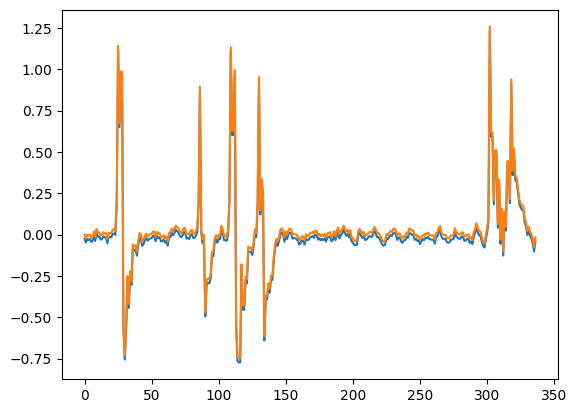

In [177]:
plt.plot(trial["IMU_Linear_Acc_Y"]-np.mean(trial["IMU_Linear_Acc_Y"]))
plt.plot(trial["IMU_Linear_Acc_Y"]-(trial["IMU_Linear_Acc_Y"][0]))

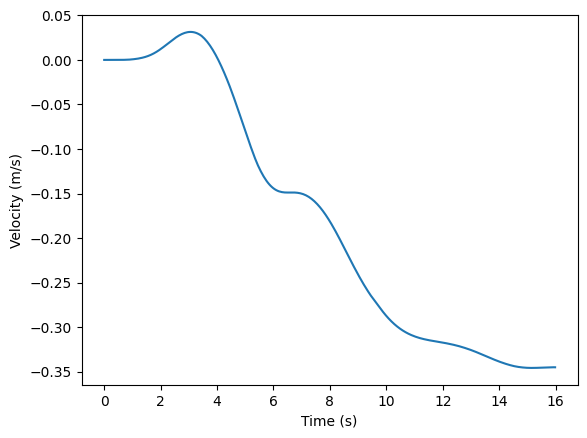

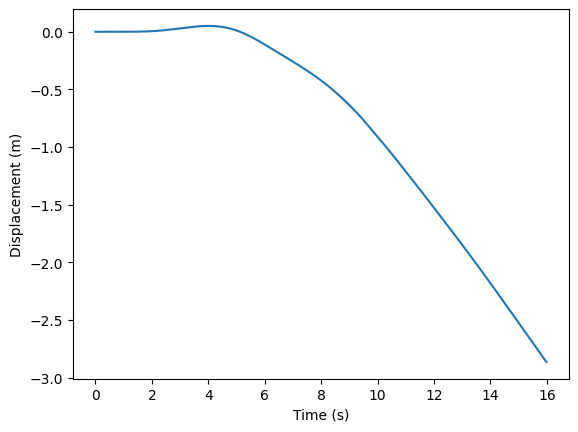

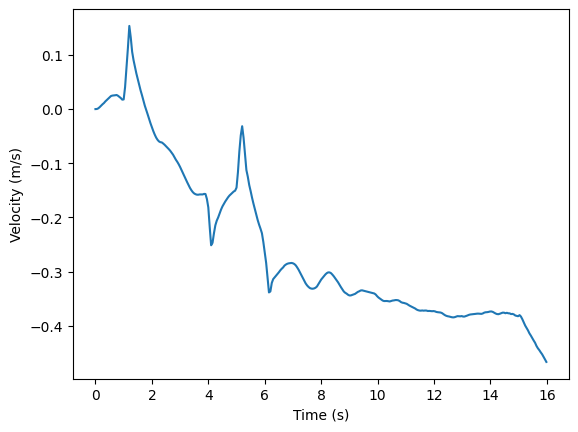

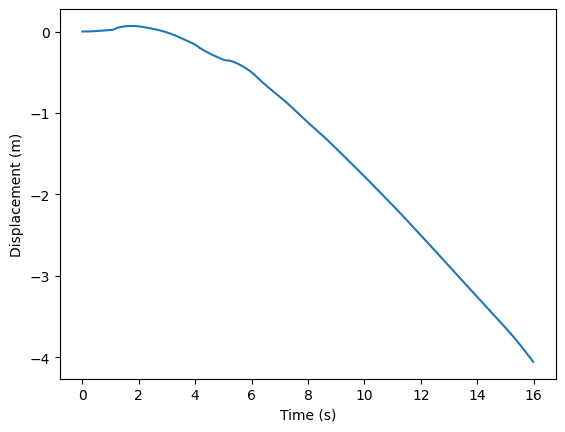

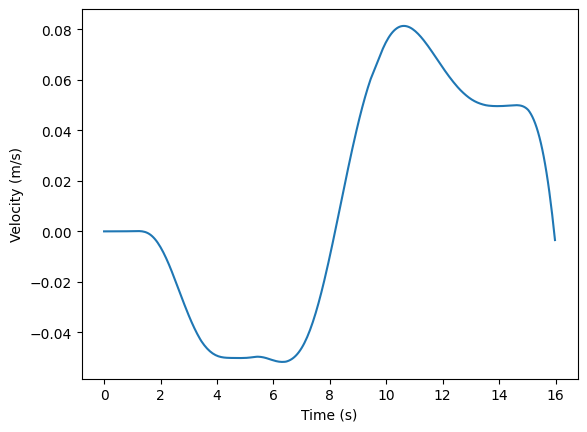

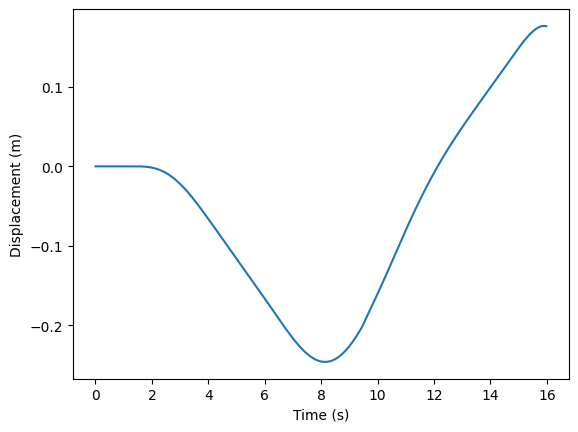

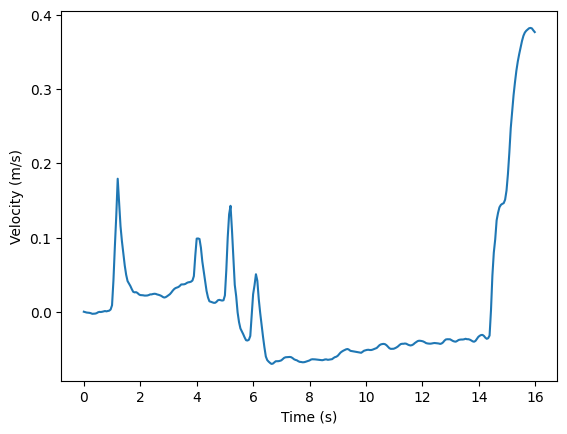

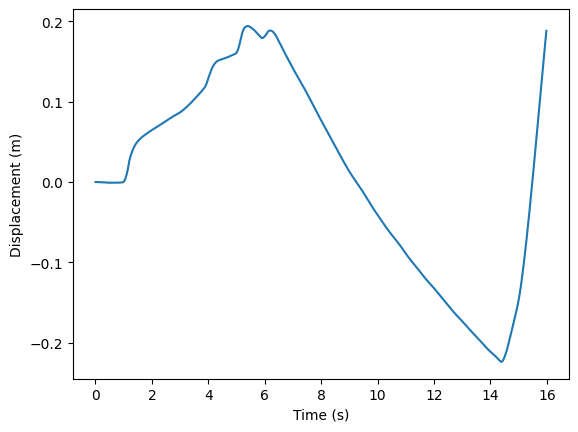

In [187]:
def create_v_d(accs,imus):
    window=0
    iterator=0
    value=0
    vels=[]
    prev_time=imus.iloc[0]["Timestamp"]
    
    prev_acc=0
    prev_vel=0
    for x in imus.iloc:
        bias=imus.iloc[window][accs]
            #Avg acc * dt = dv
        vel_d=0.5*(prev_acc+x[accs]-2*bias)*(x["Timestamp"]-prev_time)
        #vel=vel_d
        vel=prev_vel+vel_d
        prev_vel=vel
        prev_time=x["Timestamp"]
        prev_acc=x[accs]
        vels.append(vel)
        iterator+=1
        if(value!=0):
            if(iterator%value==0):
                window+=value
    plt.figure()
    plt.ylabel("Velocity (m/s)")
    plt.xlabel("Time (s)")
    plt.plot(np.array(imus.iloc[:]["Timestamp"]-imus["Timestamp"][0]),vels)
    i=0
    prev_s=0
    prev_v=0
    prev_time=imus.iloc[0]["Timestamp"]
    dists=[]
    window=0
    iterator=0
    for x in imus.iloc:
        bias=imus.iloc[window][accs]
            #Avg acc * dt = dv
        s=prev_s+vels[i]*(x["Timestamp"]-prev_time)+0.5*0.5*(prev_acc+x[accs]-2*bias)*np.square(x["Timestamp"]-prev_time)
        #s=prev_s+(vels[i])*(x["Timestamp"]-prev_time)
        prev_s=s
        prev_vel=vels[i]
        prev_acc=x[accs]
        prev_time=x["Timestamp"]
        dists.append(s)
        i+=1
        iterator+=1
        if(value!=0):
            if(iterator%value==0):
                window+=value
    plt.figure()
    plt.ylabel("Displacement (m)")
    plt.xlabel("Time (s)")
    plt.plot(np.array(imus.iloc[:]["Timestamp"]-imus["Timestamp"][0]),dists)
    return vels,dists
#z_v,z_d=create_v_d("IMU_Raw_z",df2)
#y_v,y_d=create_v_d("IMU_Raw_y",df2)
#x_v,x_d=create_v_d("IMU_Raw_x",df2)
#z_v_st,z_d_st=create_v_d("IMU_Linear_Acc_Z",df2_st)
#y_v_st,y_d_st=create_v_d("IMU_Linear_Acc_Y",df2_st)
#x_v_st,x_d_st=create_v_d("IMU_Linear_Acc_X",df2_st)
x_v_nt_st,x_d_nt_st=create_v_d("Filtered_X",trial)

y_v_nt_st,y_d_nt_st=create_v_d("IMU_Linear_Acc_X",trial)

x_v_nt_st,x_d_nt_st=create_v_d("Filtered_Y",trial)

y_v_nt_st,y_d_nt_st=create_v_d("IMU_Linear_Acc_Y",trial)

#z_v_nt_st,z_d_nt_st=create_v_d("IMU_Linear_Acc_Z",trial)

In [116]:
trial

,Timestamp,IMU_Linear_Acc_X,IMU_Linear_Acc_Y,IMU_Linear_Acc_Z,Filtered_X,Filtered_Y,Filtered_Z,Pose_X,Pose_Y,Pose_Z
0,1.730866e+09,-1.685769,1.189800,-9.920260,0.000222,-0.000222,-0.083451,7.557963e-09,-4.719602e-09,-0.000332
1,1.730866e+09,-1.686240,1.163827,-9.893605,0.000260,-0.000309,-0.112242,7.868608e-09,-4.949489e-09,-0.000332
2,1.730866e+09,-1.646482,1.109601,-9.926274,0.000292,-0.000417,-0.147216,1.068388e-08,-7.315302e-09,-0.000333
3,1.730866e+09,-1.652518,1.072100,-9.886635,0.000315,-0.000545,-0.188950,1.215293e-08,-8.716760e-09,-0.000334
4,1.730866e+09,-1.646067,1.170540,-9.888028,0.000329,-0.000692,-0.237982,1.524324e-08,-1.208675e-08,-0.000335
...,...,...,...,...,...,...,...,...,...,...
1493,1.730866e+09,-1.730593,0.729409,-9.907380,0.001680,-0.002722,-10.639958,4.795691e+00,-1.190545e+00,-23515.479227
1494,1.730866e+09,-1.713769,0.698393,-9.910694,0.001899,-0.003115,-10.638666,4.801943e+00,-1.190580e+00,-23550.956015
1495,1.730866e+09,-1.680340,0.684205,-9.852100,0.002129,-0.003514,-10.637330,4.808264e+00,-1.190623e+00,-23586.819743
1496,1.730866e+09,-1.680340,0.684205,-9.852100,0.002368,-0.003913,-10.635959,4.814611e+00,-1.190676e+00,-23622.829337


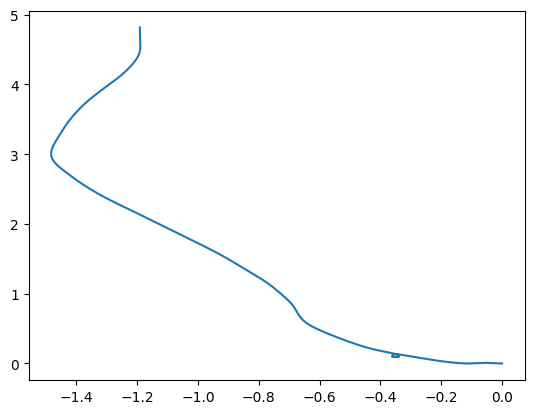

In [121]:
plt.plot(trial["Pose_Y"],trial["Pose_X"])

In [167]:
imus[0]

'/home/saab/Desktop/2024_UWR/Analysis/output_IMU_case_1302_t2_.csv'

In [168]:
trial2=pd.read_csv(imus[0])

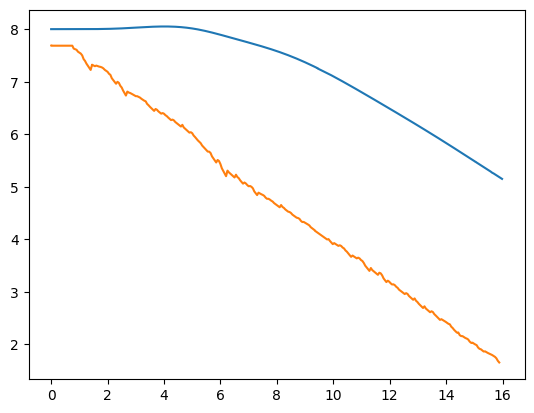

In [183]:
plt.plot(trial["Timestamp"]-trial["Timestamp"][0],trial["Pose_X"]+8)
plt.plot(trial2["Timestamp"]-trial2["Timestamp"][0],trial2["Pose_Y"])

In [158]:
len(trial2)

1601

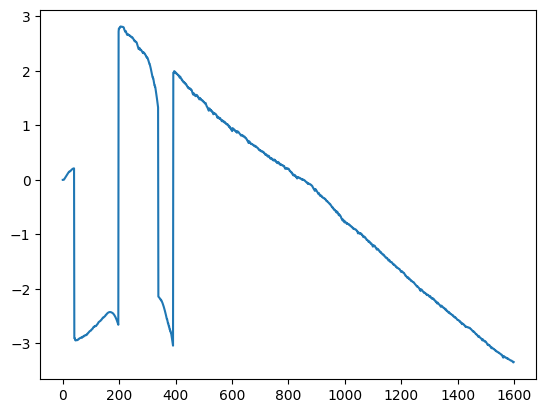

In [ ]:
plt.plot(trial2[])

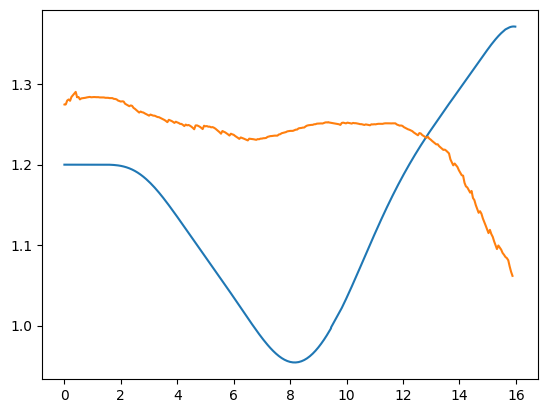

In [185]:
plt.plot(trial["Timestamp"]-trial["Timestamp"][0],trial["Pose_Y"]+1.2)
plt.plot(trial2["Timestamp"]-trial2["Timestamp"][0],trial2["Pose_X"])

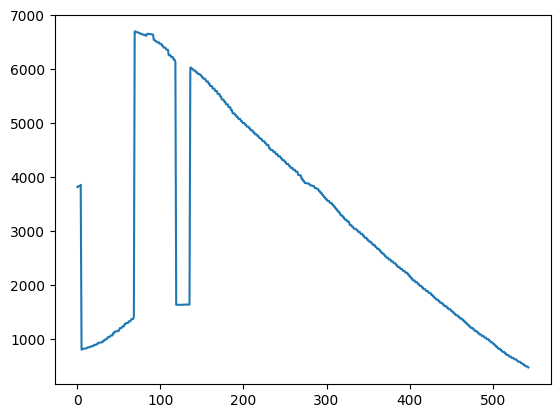

In [148]:
trial3=pd.read_csv(confidence_cases[0])
plt.plot(trial3["Sonar_distance_2"])